# Global Health and Life Expectancy Analysis: Descriptive Insights for 2015
## Second Notebook: Data Preparation and Transformations

Building on the descriptive insights from the first notebook, this notebook focuses on preparing the dataset for statistical analyses and visualizations.

Specifically, we will:  
- Apply transformations to continuous variables to reduce skewness and improve interpretability.  
- Organize the dataset for easier comparison between developed and developing countries.  
- Ensure the data is ready for meaningful statistical analyses and visualizations that highlight patterns in health, economic, and education indicators for 2015.

This notebook sets the stage for robust analysis of how economic development shapes key health outcomes across the world.

**Author:** J-F Jutras  
**Date:** December 2025  
**Dataset:** Life Expectancy — WHO and United Nations (Kaggle)


## 2.1-Data Loading and Overview

In [1]:
import pandas as pd
import os
import kagglehub

#Download latest version of the dataset
path = kagglehub.dataset_download("lashagoch/life-expectancy-who-updated")

#Define dataset path
dataset_dir = "/kaggle/input/life-expectancy-who-updated"
csv_path = os.path.join(dataset_dir, "Life-Expectancy-Data-Updated.csv")

#Load full dataset
df = pd.read_csv(csv_path)

#Keep only year 2015
df = df[df["Year"] == 2015].reset_index(drop=True)

| Column Name                     | Description                                                                                                       |
|---------------------------------|-------------------------------------------------------------------------------------------------------------------|
| Country                         | Country name                                                                                                      |
| Region                          | Region classification (9 regions)                                                                                 |
| Year                            | Year of observation (2015)                                                                                             |
| Infant_deaths                    | Number of infant deaths per 1000 population                                                                       |
| Under_five_deaths                | Number of deaths of children under five per 1000 population                                                      |
| Adult_mortality                  | Probability of dying between ages 15 and 60 per 1000 population (both sexes)                                     |
| Alcohol_consumption              | Recorded per capita (15+) alcohol consumption, in litres of pure alcohol                                          |
| Hepatitis_B                      | Hepatitis B immunization coverage among 1-year-olds (%)                                                           |
| Measles                          | Number of reported measles cases per 1000 population                                                              |
| BMI                              | Average Body Mass Index of the population                                                                         |
| Polio                            | Polio immunization coverage among 1-year-olds (%)                                                                 |
| Diphtheria                       | Diphtheria, tetanus toxoid and pertussis (DTP3) immunization coverage among 1-year-olds (%)                       |
| Incidents_HIV                     | Deaths per 1000 live births due to HIV/AIDS (ages 0–4)                                                           |
| GDP_per_capita                    | Gross Domestic Product per capita (USD)                                                                          |
| Population_mln                    | Population of the country in millions                                                                             |
| Thinness_ten_nineteen_years       | Prevalence of thinness among individuals aged 10–19 years (%)                                                    |
| Thinness_five_nine_years          | Prevalence of thinness among individuals aged 5–9 years (%)                                                      |
| Schooling                         | Average number of years of schooling                                                                             |
| Economy_status_Developed          | Binary indicator (1 = developed, 0 = not developed)                                                              |
| Economy_status_Developing         | Binary indicator (1 = developing, 0 = not developing)                                                            |
| Life_expectancy                   | Average life expectancy at birth (in years)                                                                      |


## 2.2-Data Preparation

Before conducting any statistical analyses, it is essential to assess the quality of the dataset. In the first notebook, we performed a thorough examination of the data, and the following observations were made:

- **Completeness:** The dataset contains **no missing values** across all 21 variables, covering 179 countries and 16 years (2000–2015). This eliminates the need for imputation or removal of incomplete records.  
- **Duplicates:** There are **no duplicate rows**, ensuring that each observation is unique and representative.  
- **Data types:** All columns have **appropriate data types** (numeric for continuous measures, integer for counts and binary indicators, and object/string for categorical variables), so no type conversions are required.  
- **Outliers:** Several variables contain **extreme values** (e.g., GDP per capita, HIV incidence, population), but these represent real-world phenomena rather than errors. As such, these outliers will be accounted for in subsequent transformations and analyses rather than removed.  
- **Consistency and validity:** Categorical variables, such as `Region` and economic status indicators, are consistent with the dataset documentation. Continuous variables fall within plausible ranges according to global health and socioeconomic data.  

Given the high-quality state of the dataset, traditional data cleaning steps like missing value imputation, duplicate removal, and type correction are **not required**.  

## 2.3-Principal Component Analysis

In [2]:
#Clone the public GitHub repository "jfj-utils" into the current Kaggle working directory.
#This downloads all files and folders from the repo so they can be used in the notebook.
!rm -rf /kaggle/working/jfj-utils
!git clone https://github.com/jfjutras07/jfj-utils.git

#Add the cloned repository to the Python path so Python can import modules from it
import sys
sys.path.append("/kaggle/working/jfj-utils")

Cloning into 'jfj-utils'...
remote: Enumerating objects: 437, done.
remote: Counting objects: 100% (58/58), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 437 (delta 32), reused 2 (delta 2), pack-reused 379 (from 2)
Receiving objects: 100% (437/437), 148.48 KiB | 7.07 MiB/s, done.
Resolving deltas: 100% (241/241), done.


We will start by reexamining the Spearman correlation results obtained in Notebook 1 to identify the strength and direction of relationships between key variables. In addition, we will assess multicollinearity using the Variance Inflation Factor (VIF), which will help us determine which transformations or adjustments are necessary for our subsequent statistical analyses.

In [3]:
#Define numeric cols
numeric_cols = [
    'Infant_deaths',
    'Under_five_deaths',
    'Adult_mortality',
    'Alcohol_consumption',
    'BMI',
    'Incidents_HIV',
    'GDP_per_capita',
    'Population_mln',
    'Schooling',
    'Thinness_ten_nineteen_years',
    'Thinness_five_nine_years',
    'Life_expectancy'
]

#Import the check_multicollinearity function
from eda.multicollinearity import check_multicollinearity
numeric_df = df[numeric_cols]
results = check_multicollinearity(numeric_df)
results

{'correlation_matrix':                              Infant_deaths  Under_five_deaths  \
 Infant_deaths                        1.000              0.998   
 Under_five_deaths                    0.998              1.000   
 Adult_mortality                      0.871              0.877   
 Alcohol_consumption                 -0.568             -0.567   
 BMI                                 -0.508             -0.516   
 Incidents_HIV                        0.565              0.568   
 GDP_per_capita                      -0.854             -0.862   
 Population_mln                       0.085              0.097   
 Schooling                           -0.850             -0.857   
 Thinness_ten_nineteen_years          0.641              0.645   
 Thinness_five_nine_years             0.657              0.659   
 Life_expectancy                     -0.932             -0.936   
 
                              Adult_mortality  Alcohol_consumption    BMI  \
 Infant_deaths                          0

At the end of Notebook 1, we intended to focus on four key indicators: **Life Expectancy, BMI, Schooling, and Adult Mortality**. These variables are central to our research question:

**"How does a country’s level of economic development influence key health outcomes - in 2015?"**

However, the Spearman correlation matrix and VIF analysis reveal substantial multicollinearity:

- **Spearman correlations:** Life Expectancy, Adult Mortality, BMI, and Schooling are strongly interrelated.
- **VIF values:** Extremely high (e.g., Life Expectancy ~250, BMI ~275), indicating that using these variables directly in multivariate tests would produce unstable estimates.

We cannot reliably use these four variables as-is in regression or other statistical tests. To overcome multicollinearity while preserving the core information in these indicators, we will apply **Principal Component Analysis (PCA)**. PCA will:

- Transform correlated variables into orthogonal components.
- Allow us to summarize health and socioeconomic patterns without redundancy.
- Enable robust statistical testing to assess the association between economic development and health outcomes.

This approach ensures that our subsequent analyses are statistically sound and interpretable, aligning with best practices in multivariate health data analysis.

In [4]:
from sklearn.preprocessing import StandardScaler
import numpy as np

#The following variables are selected to construct a composite health outcome : Life expectancy, BMI, and
#adult mortality are direct health indicators and exhibit strong multicollinearity based on Spearman
#correlations and VIF diagnostics. Schooling is intentionally excluded from the PCA because it represents
#a socioeconomic determinant rather than a health outcome, and keeping it separate preserves
#interpretability for subsequent statistical analyses.
new_variable = [
'Life_expectancy',
'BMI',
'Adult_mortality']

#Extract numeric data for scaling
X = df[new_variable]

#Initialize a StandardScaler to standardize features
scaler = StandardScaler()

# Fit the scaler to the data and transform it
X_scaled = scaler.fit_transform(X)

In [5]:
from sklearn.decomposition import PCA

#Initialize PCA and retain enough components to explain 95% of the total variance
pca = PCA(n_components=0.95)

#Fit PCA on the standardized data and transform it into principal components
X_pca = pca.fit_transform(X_scaled)

#Create column names for the principal components
pca_cols = [f'PC{i+1}' for i in range(X_pca.shape[1])]

#Convert the PCA output into a DataFrame for easier handling and interpretation
df_pca = pd.DataFrame(X_pca, columns=pca_cols)

#Display the first rows of the transformed dataset
print(df_pca.head())
print("\nExplained variance ratio for each component:", pca.explained_variance_ratio_)

        PC1       PC2
0 -1.280928  0.455012
1 -1.726479 -0.710615
2  0.299416  0.494500
3  2.610301  0.737659
4  1.891440  0.128909

Explained variance ratio for each component: [0.77875135 0.20465643]


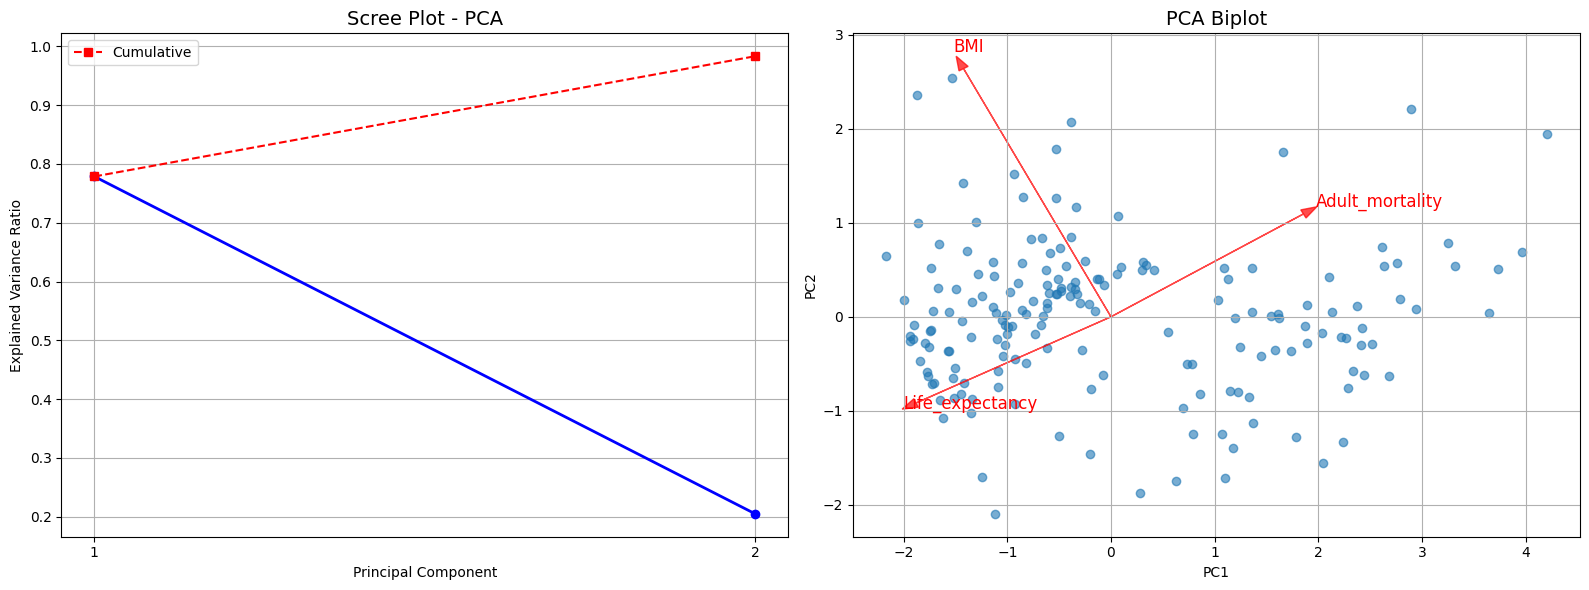

In [6]:
import matplotlib.pyplot as plt

#Prepare PCA results
pca_components = pca.components_
explained_var = pca.explained_variance_ratio_

#Create figure with 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(16,6))

#Scree plot
axes[0].plot(range(1, len(explained_var)+1), explained_var, 'o-', linewidth=2, color='blue')
axes[0].set_title('Scree Plot - PCA', fontsize=14)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_xticks(range(1, len(explained_var)+1))
axes[0].grid(True)

#Cumulative variance
cumulative_var = explained_var.cumsum()
axes[0].plot(range(1, len(explained_var)+1), cumulative_var, 's--', color='red', label='Cumulative')
axes[0].legend()

#PCA Biplot (PC1 vs PC2)
axes[1].scatter(df_pca['PC1'], df_pca['PC2'], alpha=0.6)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('PCA Biplot', fontsize=14)

#Add arrows for variable loadings
for i, var in enumerate(new_variable):
    axes[1].arrow(0, 0, 
                  pca_components[0, i]*3,  
                  pca_components[1, i]*3,
                  color='red', alpha=0.7, head_width=0.1)
    axes[1].text(pca_components[0, i]*3.2, pca_components[1, i]*3.2, var, color='red', fontsize=12)

axes[1].grid(True)

plt.tight_layout()
plt.show()

The PCA conducted on *Life Expectancy*, *BMI*, and *Adult Mortality* yields two principal components that together explain approximately **97.8% of the total variance** in the original variables.

- **PC1** explains nearly **77.8% of the variance** and represents the dominant health dimension across countries. This component summarizes overall population health by jointly capturing variation in life expectancy, nutritional status, and adult mortality.
- **PC2** accounts for an additional **20% of the variance**, reflecting secondary patterns in health outcomes that are independent of the primary health gradient captured by PC1.

In [7]:
#We retain only the first principal component (PC1) because it explains the vast majority of the total
#variance (~80%) across Life Expectancy, BMI, and Adult Mortality. PC1 therefore serves as a robust
#composite health index, effectively addressing multicollinearity issues identified through Spearman
#correlations and VIF diagnostics. 

#Add PC1 to the original dataset
df['PC1_health_index'] = df_pca['PC1']

#Use the check_multicollinearity function again
final_cols = [
    'Alcohol_consumption',
    'Incidents_HIV',
    'GDP_per_capita',
    'Population_mln',
    'Schooling',
    'PC1_health_index'
]
final_df = df[final_cols]
results = check_multicollinearity(final_df)
results

{'correlation_matrix':                      Alcohol_consumption  Incidents_HIV  GDP_per_capita  \
 Alcohol_consumption                1.000         -0.076           0.562   
 Incidents_HIV                     -0.076          1.000          -0.406   
 GDP_per_capita                     0.562         -0.406           1.000   
 Population_mln                    -0.097         -0.102          -0.154   
 Schooling                          0.639         -0.434           0.793   
 PC1_health_index                  -0.373          0.574          -0.830   
 
                      Population_mln  Schooling  PC1_health_index  
 Alcohol_consumption          -0.097      0.639            -0.373  
 Incidents_HIV                -0.102     -0.434             0.574  
 GDP_per_capita               -0.154      0.793            -0.830  
 Population_mln                1.000     -0.092             0.125  
 Schooling                    -0.092      1.000            -0.744  
 PC1_health_index              0.125

Following the construction of the PCA-based health index (`PC1_health_index`), multicollinearity was reassessed using Spearman correlation coefficients and Variance Inflation Factors (VIF).

The Spearman correlation matrix indicates that `PC1_health_index` exhibits strong and theoretically consistent associations with key socioeconomic variables, notably GDP per capita and schooling. While the correlation with schooling is relatively high (ρ ≈ −0.74), it remains below thresholds typically associated with problematic redundancy and is conceptually meaningful.

VIF diagnostics further confirm that multicollinearity is no longer an issue. All variables present VIF values below standard thresholds (VIF < 5), suggesting that each predictor contributes independent information to the model.

The objective of this exercise is to enable a broad range of inferential statistical tests. Consequently, results involving `PC1_health_index` and schooling should be interpreted with appropriate caution, acknowledging their conceptual linkage without compromising statistical validity.

## 2.4-Data Transformation

In [8]:
#Determine the best transformation to reduce skewness
from eda.best_transformations import best_transformation

#Loop columns to determine the best transformation
for col in final_df.select_dtypes(include = np.number).columns:
    print(f"Column: {col}")
    best_method, orig_skew, trans_skew = best_transformation(final_df[col])
    print(f"  Best method: {best_method}")
    print(f"  Original skew: {orig_skew:.3f}")
    print(f"  Transformed skew: {trans_skew:.3f}\n")

Column: Alcohol_consumption
  Best method: yeojohnson
  Original skew: 0.493
  Transformed skew: 0.114

Column: Incidents_HIV
  Best method: boxcox
  Original skew: 5.366
  Transformed skew: 0.014

Column: GDP_per_capita
  Best method: boxcox
  Original skew: 2.329
  Transformed skew: 0.005

Column: Population_mln
  Best method: boxcox
  Original skew: 8.056
  Transformed skew: 0.000

Column: Schooling
  Best method: yeojohnson
  Original skew: -0.274
  Transformed skew: 0.181

Column: PC1_health_index
  Best method: yeojohnson
  Original skew: 0.743
  Transformed skew: 0.114



In [9]:
from scipy.stats import boxcox, yeojohnson

#Create a copy of the DataFrame to store transformed values
final_df_transformed = final_df.copy()

#Loop through numeric columns and apply the best transformation
for col in final_df.select_dtypes(include = np.number).columns:
    best_method, _, transformed_skew = best_transformation(final_df[col])
    
    #Apply the selected transformation
    if best_method == "log":
        final_df_transformed[col] = np.log1p(final_df[col])
    elif best_method == "sqrt":
        final_df_transformed[col] = np.sqrt(final_df[col])
    elif best_method == "boxcox":
        #Box-Cox requires strictly positive values
        final_df_transformed[col], _ = boxcox(final_df[col] + 1e-6)
    elif best_method == "yeojohnson":
        final_df_transformed[col], _ = yeojohnson(final_df[col])
    #If 'original', keep as is

#Check the first rows
print(final_df_transformed.head())

   Alcohol_consumption  Incidents_HIV  GDP_per_capita  Population_mln  \
0             0.975187      -3.136467        8.742838        4.751110   
1             3.787019      -2.959200        9.487469        4.136009   
2             3.289226      -3.136467        8.595448        5.477539   
3             2.330440       0.112272        6.888646        3.347069   
4             1.645836      -0.040959        6.216003        0.747717   

   Schooling  PC1_health_index  
0  10.161634         -1.660425  
1  13.014444         -2.389815  
2  16.590271          0.278442  
3   7.700595          1.753126  
4   4.015624          1.370985  


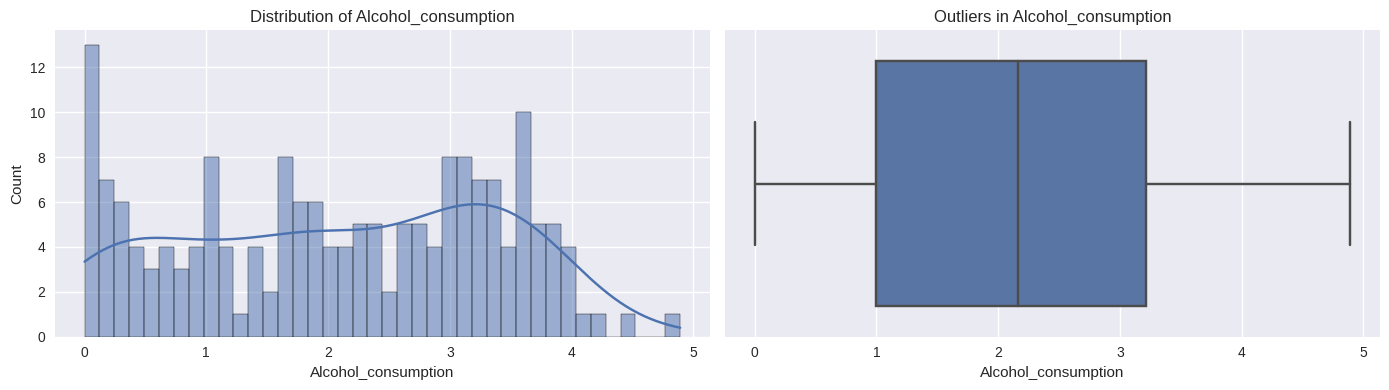

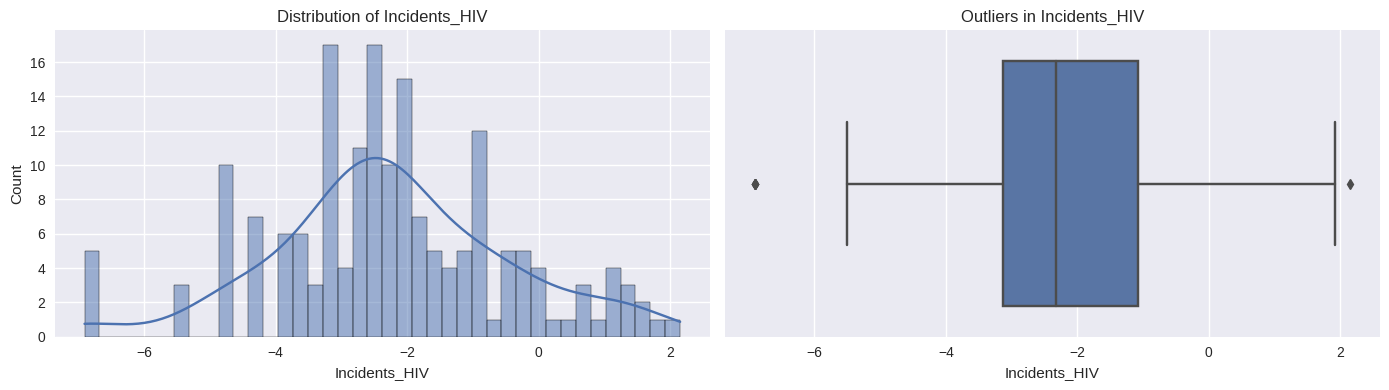

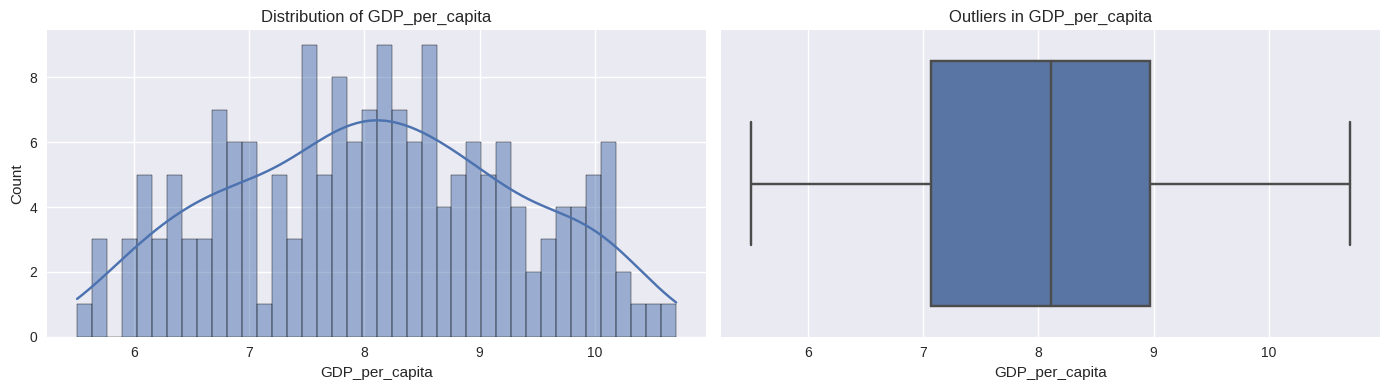

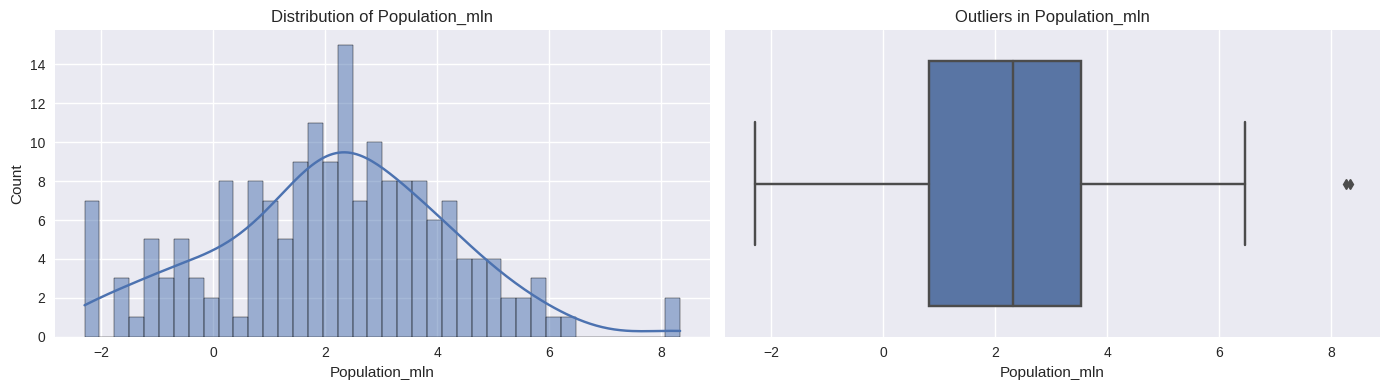

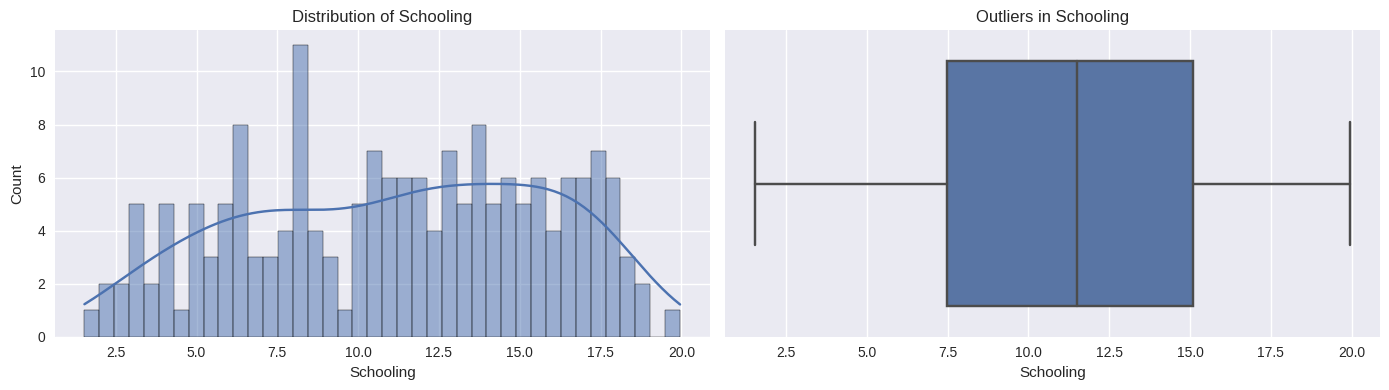

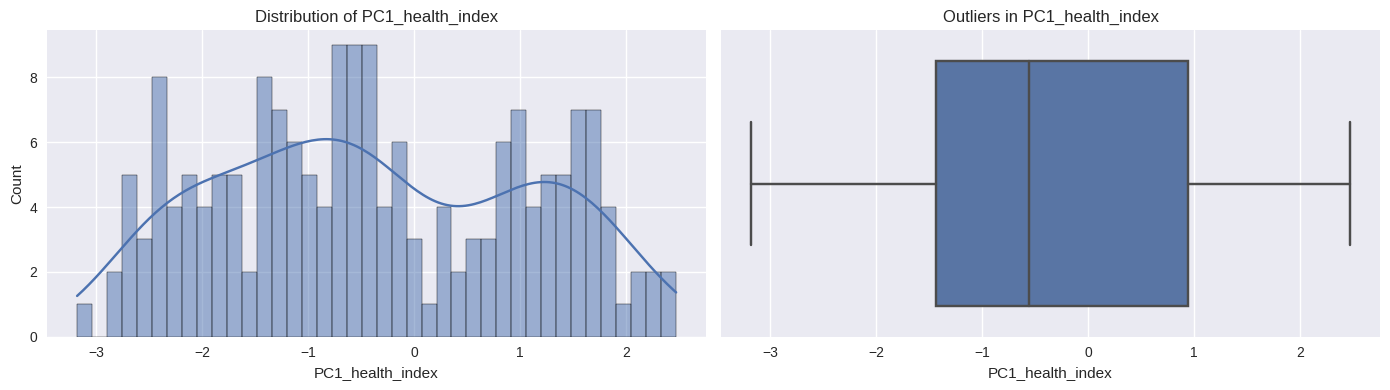

In [10]:
#Plot histograms, KDEs, and boxplots for the specified numeric columns
from visualization.explore_continuous import plot_numeric_distribution
plot_numeric_distribution(final_df_transformed, final_df)

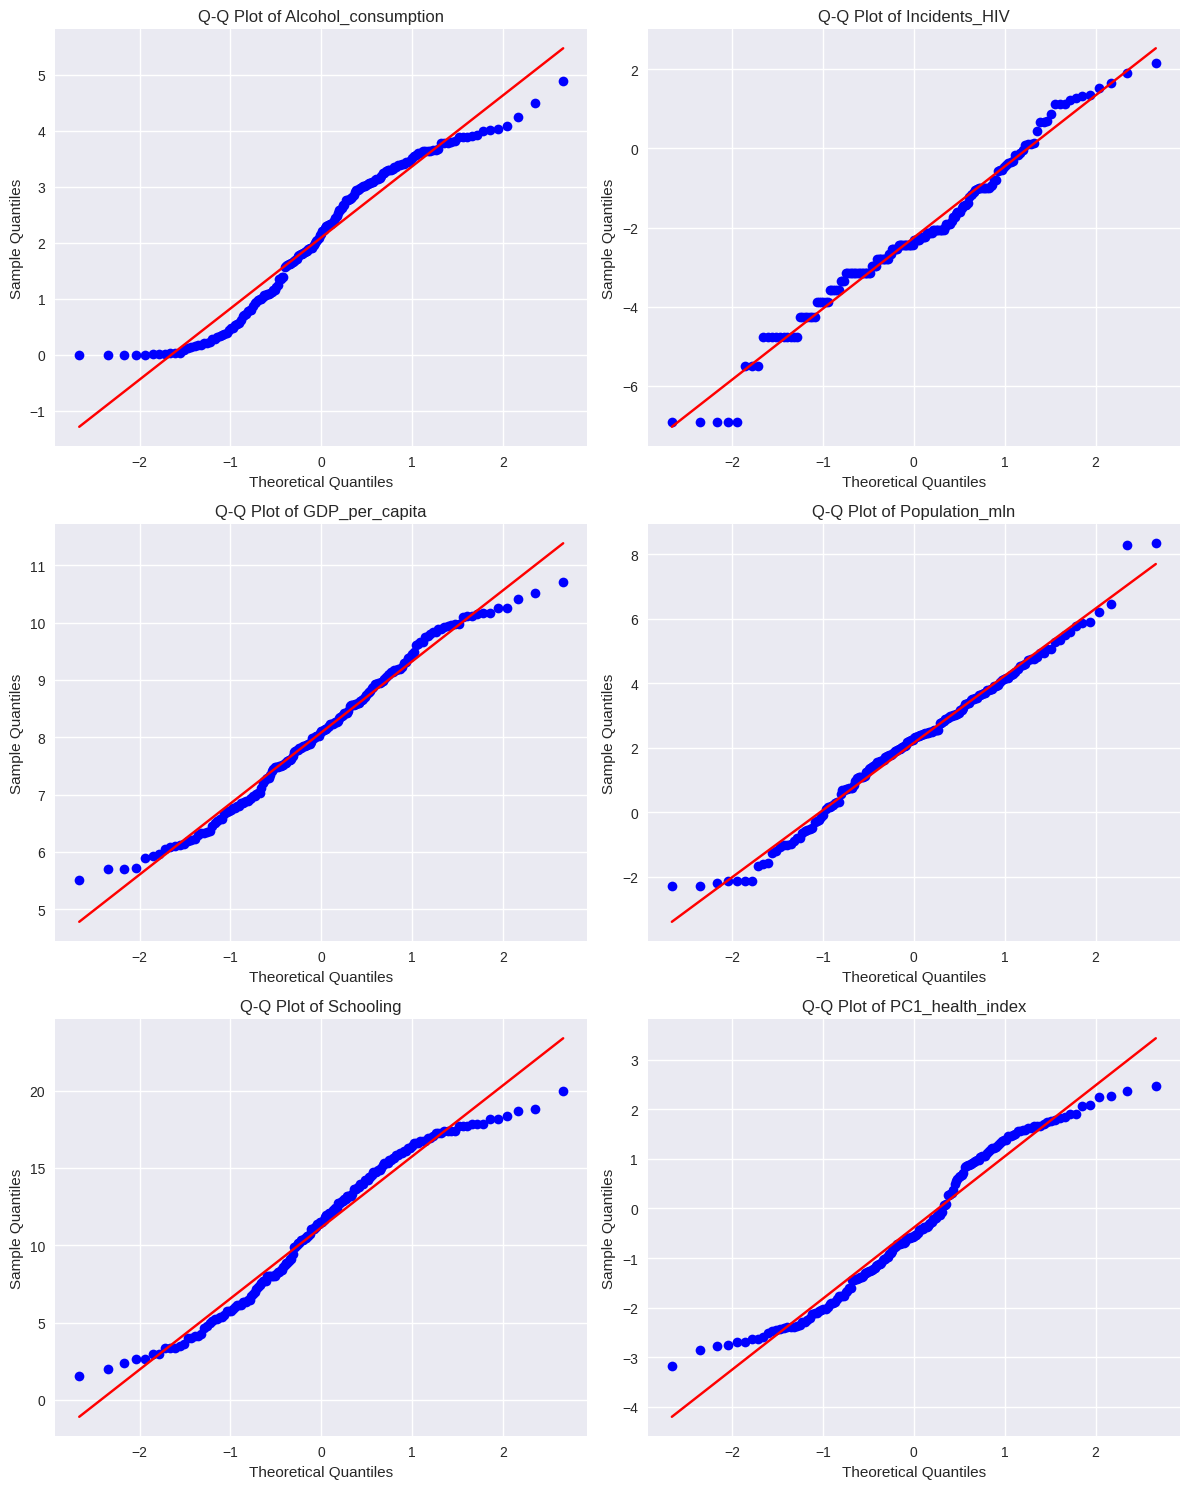

In [11]:
#Visualize qq plots
from visualization.explore_continuous import qq_plot_numeric
qq_plot_numeric(final_df_transformed)

In [12]:
#Use a function to apply normality tests
import pandas as pd
import numpy as np
from scipy.stats import shapiro, normaltest, anderson, kstest, norm

def normality_check(df, numeric_cols=None):
    if numeric_cols is None:
        numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    
    results = []
    
    for col in numeric_cols:
        s = df[col].dropna()
        n = len(s)
        col_mean = s.mean()
        col_std = s.std()
        
        #Initialize flags
        shapiro_flag = np.nan
        dagostino_flag = np.nan
        anderson_flag = np.nan
        ks_flag = np.nan
        
        #Shapiro-Wilk
        if n <= 5000:
            _, p = shapiro(s)
            shapiro_flag = p > 0.05
        
        #D’Agostino K^2
        if n > 20:
            _, p = normaltest(s)
            dagostino_flag = p > 0.05
        
        #Anderson-Darling (5%)
        ad_result = anderson(s)
        crit_val_5 = ad_result.critical_values[2]
        ad_stat = ad_result.statistic
        anderson_flag = ad_stat < crit_val_5
        
        #Kolmogorov-Smirnov against normal
        _, ks_p = kstest(s, 'norm', args=(col_mean, col_std))
        ks_flag = ks_p > 0.05
        
        results.append({
            "Column": col,
            "N": n,
            "Mean": col_mean,
            "Std": col_std,
            "Shapiro-Wilk": shapiro_flag,
            "D’Agostino K²": dagostino_flag,
            "Anderson-Darling (5%)": anderson_flag,
            "Kolmogorov-Smirnov": ks_flag
        })
    
    return pd.DataFrame(results)

normality_results = normality_check(final_df_transformed)
normality_results

,Column,N,Mean,Std,Shapiro-Wilk,D’Agostino K²,Anderson-Darling (5%),Kolmogorov-Smirnov
0,Alcohol_consumption,179,2.092823,1.285291,False,False,False,True
1,Incidents_HIV,179,-2.251323,1.794739,False,True,False,True
2,GDP_per_capita,179,8.082060,1.236481,False,False,True,True
3,Population_mln,179,2.148526,2.071771,True,True,True,True
4,Schooling,179,11.142006,4.624638,False,False,False,True
5,PC1_health_index,179,-0.385185,1.444285,False,False,False,True


Normality tests applied after transformation indicate that most variables do not strictly
follow a Gaussian distribution according to multiple statistical criteria. This outcome is
expected in cross-country health and socioeconomic data, even after variance-stabilizing
transformations.

Importantly, strict normality of the variables themselves is not a prerequisite for the
planned analyses. Subsequent statistical methods will either rely on assumptions about the
distribution of residuals rather than raw variables, or use approaches that are robust to
non-normality.

## 2.5 Update and Save Dataset

In [13]:
#Define the columns to keep for the final dataset
final_columns = [
    'Country',
    'Region',
    'Year',
    'Economy_status_Developed',
    'Economy_status_Developing',
    'PC1_health_index',
    'Alcohol_consumption',
    'Incidents_HIV',
    'GDP_per_capita',
    'Population_mln',
    'Schooling'
]

#Create the final dataset by selecting the specified columns
final_dataset = df[final_columns].copy()

#Overwrite final_df to keep a standard name
final_df = final_dataset

#Save the final dataset as a CSV file
final_df.to_csv("final_dataset_for_notebook3.csv", index = False)

print("Final dataset created and saved as 'final_dataset_for_notebook3.csv'.")

Final dataset created and saved as 'final_dataset_for_notebook3.csv'.


**Key Takeaways**

**Composite Health Index (PC1_health_index)**

- Principal Component Analysis (PCA) was applied to core health variables (Life Expectancy, Adult Mortality, and BMI) for the year 2015, producing a composite health index (PC1_health_index) that captures approximately 80% of the total variance.
- This composite index effectively summarizes highly correlated health outcomes into a single dimension, addressing multicollinearity observed in pairwise correlations and variance inflation diagnostics.

**Interpretation of Principal Components**

- PC1 represents overall population health, with higher scores associated with higher life expectancy, lower adult mortality, and improved nutritional status (BMI).
- PC2 captures secondary and orthogonal variation in health outcomes, reflecting contextual or regional differences that are not explained by the dominant health gradient captured by PC1.

**Role of Data Transformations**

- Several continuous variables (GDP per capita, population size, alcohol consumption, HIV incidence, and PC1_health_index) were assessed for distributional properties and transformed using Box-Cox, Yeo-Johnson, logarithmic, or square-root transformations where appropriate.
- These transformations reduced skewness and stabilized variance, improving comparability across countries; however, strict statistical normality was not fully achieved, which is expected in cross-country socioeconomic and health data.

**Multicollinearity and Variable Structure**

- Following PCA and variable transformations, all retained predictors exhibit acceptable multicollinearity levels (VIF < 5), indicating sufficient independence for multivariate descriptive analysis.
- Remaining correlations are conceptually meaningful and consistent with the research framework, notably the positive association between the composite health index, GDP per capita, and schooling.

**Analytical Readiness**

- The resulting dataset is well-prepared for cross-country and cross-region descriptive comparisons in 2015.
- The combination of PCA and targeted transformations ensures that multivariate patterns are not driven by redundant or highly skewed variables, providing a robust foundation for subsequent economic and health-related analyses.
